# Project management

from pathlib import Path

In [1]:
import spectrochempy as scp

## Project creation
We can easily create a new project to store various datasets

In [2]:
proj = scp.Project()

As we did not specify a name, a name has been attributed automatically:

In [3]:
proj.name

'Project-Project_e5edc12c'

------
To get the signature of the object, one can use the usual '?'. Uncomment the following line to check

In [4]:
# Project?

----
Let's change this name

In [5]:
proj.name = "myNMRdata"
proj

Project: myNMRdata

Now we will add a dataset to the project.

First we read the dataset (here some NMR data) and we give it some name (e.g. 'nmr n°1').

Requires the official ``spectrochempy-nmr`` plugin.
Install with: ``pip install spectrochempy[nmr]``.

In [6]:
datadir = scp.pathclean(scp.preferences.datadir)
path = datadir / "nmrdata" / "bruker" / "tests" / "nmr"

nd1 = scp.nmr.read_topspin(
    path / "topspin_1d", expno=1, remove_digital_filter=True, name="NMR_1D"
)
# Use the same dataset twice for the example (real projects would use different data)
nd2 = nd1.copy()
nd2.name = "NMR_1D_copy"

To add it to the project, we use the `add_dataset` function for a single dataset:

In [7]:
proj.add_datasets(nd1)

or `add_datasets` for several datasets.

In [8]:
proj.add_datasets(nd1, nd2)

Display its structure

In [9]:
proj

Project: myNMRdata

It is also possible to add other projects as sub-project (using the `add_project` )

## Remove an element from a project

In [10]:
proj.remove_dataset("NMR_1D")
proj

Project: myNMRdata

## Get project's elements

In [11]:
proj.add_datasets(nd1, nd2)
proj

Project: myNMRdata

We can just use the name of the element as a project attribute.

In [12]:
proj.NMR_1D

NDDataset: [complex128] pp (size: 12411)

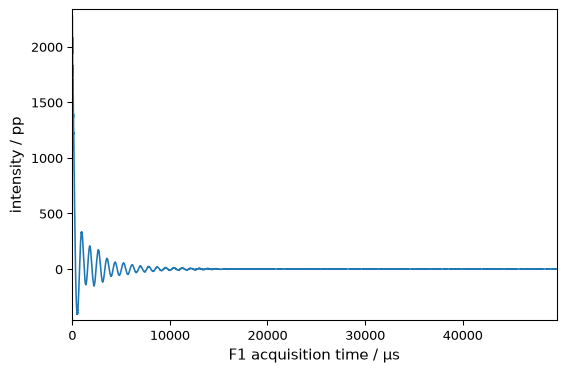

In [13]:
_ = proj.NMR_1D.plot()

However, this work only if the name contains no space, dot, comma, colon, etc.
The only special character allowed is
the underscore `_` .  If the name is not respecting this, then it is possible to use
the following syntax (as a
project behave as a dictionary). For example:

In [14]:
proj["NMR_1D"].data

array([1.08e+03-1.04e+03j, 2.28e+03-2.2e+03j, ...,    0.234+0.062j,   -0.101-0.0527j])

In [15]:
proj.NMR_1D_copy

NDDataset: [complex128] pp (size: 12411)

## Saving and loading projects

In [16]:
proj

Project: myNMRdata

#### Saving

In [17]:
proj.save_as("NMR")

PosixPath('/home/runner/work/spectrochempy/tempdirs/scp_4anuv1nx/docs/sources/userguide/objects/project/NMR.pscp')

#### Loading

In [18]:
proj2 = scp.Project.load("NMR")

In [19]:
proj2

Project: NMR

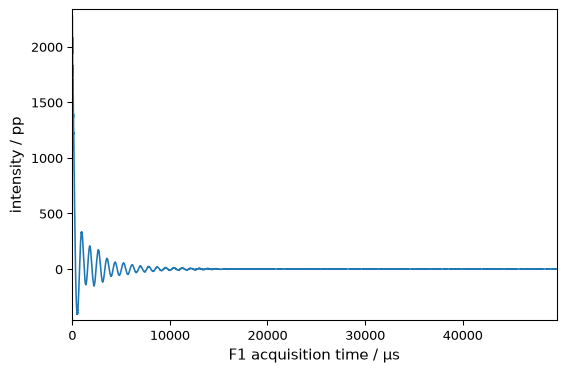

In [20]:
_ = proj2.NMR_1D.plot()

In [21]:
proj2.NMR_1D_copy

NDDataset: [complex128] pp (size: 12411)

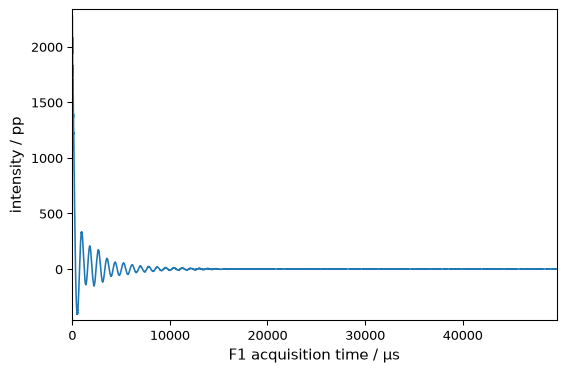

In [22]:
_ = proj.NMR_1D_copy.plot()